In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("C:/Users/Tops/Desktop/Lagchain/Classification/Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
print(df.shape)

(10000, 14)


In [8]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [10]:
for i in ['Geography','Gender', 'Age', 'Tenure','NumOfProducts', 'HasCrCard','IsActiveMember','Exited']:
    print("\n")
    print(f"______{i}______")
    print(df[i].value_counts())



______Geography______
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64


______Gender______
Gender
Male      5457
Female    4543
Name: count, dtype: int64


______Age______
Age
37    478
38    477
35    474
36    456
34    447
     ... 
84      2
82      1
88      1
85      1
83      1
Name: count, Length: 70, dtype: int64


______Tenure______
Tenure
2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: count, dtype: int64


______NumOfProducts______
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64


______HasCrCard______
HasCrCard
1    7055
0    2945
Name: count, dtype: int64


______IsActiveMember______
IsActiveMember
1    5151
0    4849
Name: count, dtype: int64


______Exited______
Exited
0    7963
1    2037
Name: count, dtype: int64


In [11]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [12]:
df1 = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
df1.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [108]:
from sklearn.preprocessing import LabelEncoder
Encoder_geo = LabelEncoder()
Encoder_gender = LabelEncoder()
df1['Geography'] = Encoder_geo.fit_transform(df1['Geography'])
df1['Gender'] = Encoder_geo.fit_transform(df1['Gender'])
df1.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [109]:
for i in ['Geography','Gender']:
    print("\n")
    print(f"______{i}______")
    print(df[i].value_counts())
    print(df1[i].value_counts())



______Geography______
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
Geography
0    5014
1    2509
2    2477
Name: count, dtype: int64


______Gender______
Gender
Male      5457
Female    4543
Name: count, dtype: int64
Gender
1    5457
0    4543
Name: count, dtype: int64


In [17]:
df1.corr()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CreditScore,1.000000,0.007888,-0.002857,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Geography,0.007888,1.000000,0.004719,0.022812,0.003739,0.069408,0.003972,-0.008523,0.006724,-0.001369,0.035943
Gender,-0.002857,0.004719,1.000000,-0.027544,0.014733,0.012087,-0.021859,0.005766,0.022544,-0.008112,-0.106512
Age,-0.003965,0.022812,-0.027544,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,0.000842,0.003739,0.014733,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,0.006268,0.069408,0.012087,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.012238,0.003972,-0.021859,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,-0.005458,-0.008523,0.005766,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,0.025651,0.006724,0.022544,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,-0.001384,-0.001369,-0.008112,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097


In [18]:
import seaborn as sns

<Axes: >

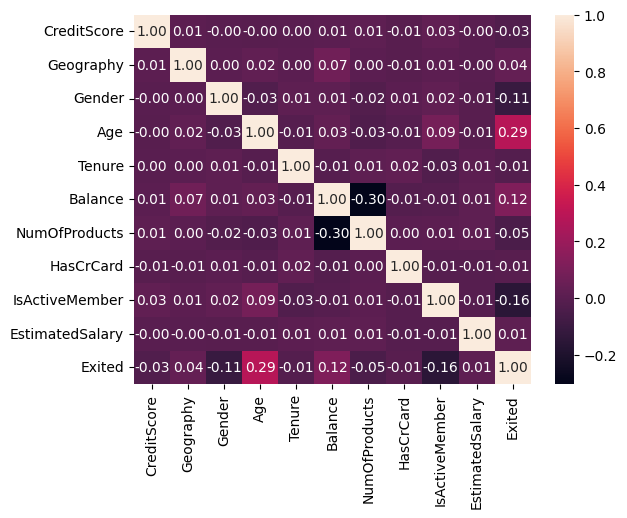

In [23]:
sns.heatmap(df1.corr(),annot=True,fmt='.2f')

In [46]:
from imblearn.over_sampling import SMOTE

In [24]:
X = df1.drop(columns=['Exited'])
Y = df1['Exited']

In [25]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X,Y,test_size=0.2,random_state=7)

In [26]:
print(Xtrain.shape)
print(Xtest.shape)
print(Ytrain.shape)
print(Ytest.shape)

(8000, 10)
(2000, 10)
(8000,)
(2000,)


In [75]:
Ytrain.value_counts()

Exited
0    6374
1    1626
Name: count, dtype: int64

In [71]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(Xtrain, Ytrain)

In [76]:
#X_resampled.shape
y_resampled.value_counts()

Exited
0    6374
1    6374
Name: count, dtype: int64

In [88]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
Xtrain_s = scaler.fit_transform(Xtrain)
Xtest_s = scaler.transform(Xtest)

#Xtrain_s = scaler.fit_transform(X_resampled)
#Xtest_s = scaler.transform(Xtest)

In [89]:
print(Xtrain.head(1))
print(Xtrain_s[0])

      CreditScore  Geography  Gender  Age  Tenure  Balance  NumOfProducts  \
4989          629          0       1   40       9      0.0              1   

      HasCrCard  IsActiveMember  EstimatedSalary  
4989          1               0           106.67  
[-0.22482832 -0.90146826  0.91578261  0.09984529  1.37778936 -1.23433145
 -0.90678651  0.64376017 -1.03667198 -1.73674714]


In [90]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
DT_model = DecisionTreeClassifier(criterion="entropy")
#DT_model.fit(Xtrain_s,y_resampled)
DT_model.fit(Xtrain_s,Ytrain)

RF_model = RandomForestClassifier()
#RF_model.fit(Xtrain_s,y_resampled)
RF_model.fit(Xtrain_s,Ytrain)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [91]:
Y_pred_dt = DT_model.predict(Xtest_s)
print(Y_pred)

Y_pred_rf = RF_model.predict(Xtest_s)
print(Y_pred)

[1 0 0 ... 0 0 0]
[1 0 0 ... 0 0 0]


In [92]:
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,ConfusionMatrixDisplay

In [93]:
ans_DT = confusion_matrix(Ytest,Y_pred_dt,labels=DT_model.classes_)
ans_RF = confusion_matrix(Ytest,Y_pred_rf,labels=RF_model.classes_)

0.794
0.4987593052109181
0.48905109489051096
0.49385749385749383


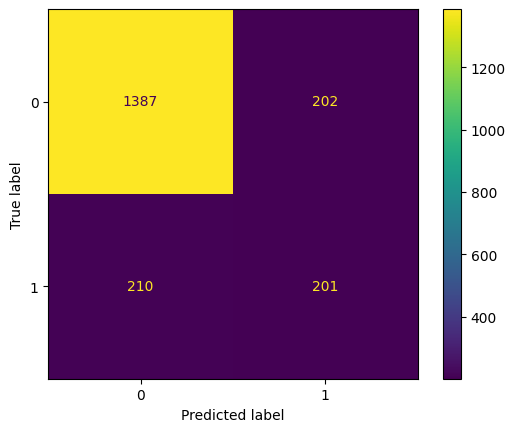

In [95]:
disp = ConfusionMatrixDisplay(confusion_matrix=ans_DT,
                              display_labels=DT_model.classes_)
disp.plot()
print(accuracy_score(Ytest,Y_pred_dt))
print(precision_score(Ytest,Y_pred_dt))
print(recall_score(Ytest,Y_pred_dt))
print(f1_score(Ytest,Y_pred_dt))

0.857
0.7551020408163265
0.45012165450121655
0.5640243902439024


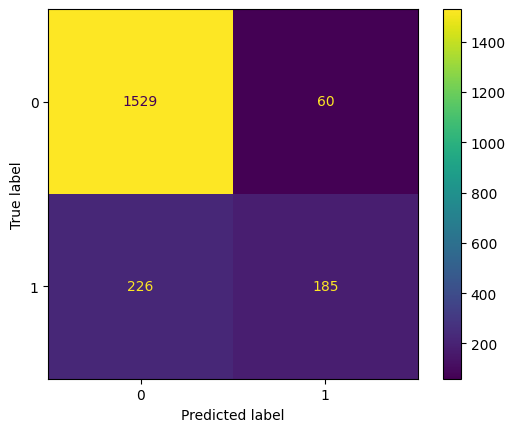

In [97]:
disp = ConfusionMatrixDisplay(confusion_matrix=ans_RF,
                              display_labels=RF_model.classes_)
disp.plot()
print(accuracy_score(Ytest,Y_pred_rf))
print(precision_score(Ytest,Y_pred_rf))
print(recall_score(Ytest,Y_pred_rf))
print(f1_score(Ytest,Y_pred_rf))

In [98]:
import joblib

In [99]:
joblib.dump(RF_model,'C:/Users/Tops/Desktop/Lagchain/Classification/RF_model.joblib')

['C:/Users/Tops/Desktop/Lagchain/Classification/RF_model.joblib']

In [105]:
import pickle

all_models = {
    'Encoder_geo': Encoder_geo,
    'Encoder_gender': Encoder_gender,
    "scaler": scaler,
    "DT_model": DT_model,
    "RF_model": RF_model
}

In [107]:
with open("C:/Users/Tops/Desktop/Lagchain/Classification/all_models.pkl", "wb") as f:
    pickle.dump(all_models, f)

TypeError: LabelEncoder.transform() missing 1 required positional argument: 'y'